# Tumour Geometric Complexity: A Contour-Only Descriptor

## 1. The problem

In radiotherapy, the achievable quality of a plan is bounded not only by the
delivery technique but by the patient's anatomy. When an organ at risk (OAR)
lies close to, or inside, the planning target volume (PTV), no amount of
re-optimisation can fully separate the two: the dose gradient that a machine can
produce is finite. In such cases the planner is forced to compromise — either
accept a violation of an OAR tolerance, or reduce the dose delivered to the PTV.

This difficulty is intrinsic to the geometry of the case. It is present before
any plan is made, yet current quality-assurance review has no measure of it: a
plan is judged pass or fail, and a failure cannot be attributed to poor planning
rather than to an anatomy that never permitted a good plan. What is missing is a
reproducible way to quantify how hard a case is, from its geometry alone.

## 2. Proposed solution

We propose to quantify this intrinsic difficulty as the **Tumour Geometric
Complexity (TGC)**, measured through a contour-only descriptor — the **Geometric
Volume Coefficient (GVC)** — computed from the delineated structures without any
dose calculation. The descriptor separates the two physical facts that govern
difficulty: volume that lies inside the target cannot be spared by any plan, and
volume lying closer to the target than the achievable dose gradient allows
cannot be spared by a real machine.

### 2.1 The differential distance-to-target histogram

The spatial relationship between an OAR and the PTV is captured by the
differential Distance-to-Target Histogram (dDTH), which records the fraction of
the OAR volume as a function of its distance $r$ from the PTV surface.

- **Abscissa** — distance from the PTV, $r$ (mm)
- **Ordinate** — normalised OAR volume fraction

The histogram is partitioned into three zones:

1. **Overlap** — volume inside the target, $r = 0$ (irreducible complexity).
2. **Near-compression** — volume within the achievable fall-off,
   $0 < r \le d_c$ (the machine limitation).
3. **Separation** — volume far enough to be spared, $r > d_c$
   (effectively free of risk).

### 2.2 Normalised zone volumes

Each OAR voxel is assigned its Euclidean distance to the nearest PTV voxel and
falls in exactly one zone. Counting the voxels in each zone gives three
dimensionless fractions:

$$
NOV = \frac{V(\text{PTV} \cap \text{OAR})}{V_{\text{OAR}}}, \qquad
NCV = \frac{V(0 < r \le d_c)}{V_{\text{OAR}}}, \qquad
NSV = \frac{V(r > d_c)}{V_{\text{OAR}}}.
$$

Because the three zones tile the organ, the fractions sum to unity:

$$
NOV + NCV + NSV = 1.
$$

### 2.3 The near-compression threshold

The boundary $d_c$ between the near-compression and separation zones is set by
machine deliverability. It is the minimum distance over which the dose can fall
from the target prescription $D_{\text{PTV}}$ to the organ tolerance
$D_{\text{OAR}}$ at the steepest achievable gradient $G$:

$$
d_c = \frac{D_{\text{PTV}} - D_{\text{OAR}}}{G}.
$$

Here $D_{\text{PTV}}$ is the clinical prescription and $D_{\text{OAR}}$ the
organ tolerance, both taken on the clinical dose scale; $G$ is the achievable
dose gradient in Gy mm$^{-1}$. Where $D_{\text{OAR}} \ge D_{\text{PTV}}$, the
threshold is clamped to $d_c = 0$: the organ is dose-safe and carries no
near-compression zone. The machine constraint therefore enters only through the
position of this boundary; the overlap term is purely anatomical and independent
of $G$.

### 2.4 The Geometric Volume Coefficient

The organ-level descriptor is a penalised sum of the three fractions,

$$
GVC = \alpha \, NOV + \beta \, NCV + \gamma \, NSV,
\qquad \alpha \ge \beta \ge \gamma \ge 0,
$$

with the overlap zone penalised most and the separation zone least. The simplest
instance satisfying this ordering, used throughout,

$$
\alpha = 1, \qquad \beta = 0.5, \qquad \gamma = 0,
\qquad\Longrightarrow\qquad GVC = NOV + \tfrac{1}{2}\,NCV,
$$

confines the coefficient to $[0, 1]$: overlap volume counts in full, near-
compression volume at half, and separation volume not at all. The GVC is thus a
normalised, contour-only descriptor of the Tumour Geometric Complexity of a
single organ, requiring no dose distribution of its own — its sole
machine-dependent input is the gradient $G$ that fixes $d_c$.

## Taking Patient DICOM as INPUT

---

In [2]:
import zipfile
import os
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.path import Path
import numpy as np
import pydicom
from scipy.ndimage import distance_transform_edt

DATA_ROOT   = os.environ.get(
    "TGC_DATA_ROOT",
    "C:\\Users\\moham\\Downloads\\Projects\\Digital_Twins"
)
zip_path     = os.path.join(DATA_ROOT, "a00286cf.zip")
extract_path = os.path.join(DATA_ROOT, "a00286cf")  

os.makedirs(extract_path, exist_ok=True)
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")
print("Files extracted to:", os.path.abspath(extract_path))

Extraction completed.
Files extracted to: C:\Users\moham\Downloads\Projects\Digital_Twins\a00286cf


In [3]:
for root, dirs, files in os.walk(extract_path):
    print(f"\nFolder: {root}")
    for file in files[:5]:
        print("  ", file)


Folder: C:\Users\moham\Downloads\Projects\Digital_Twins\a00286cf
   20220601_a00286cf_dicom_ct_dosi_004bed05b82f2c1130ba0d565de6b0a9.dcm
   20220601_a00286cf_dicom_ct_dosi_008bcf6b30b1defce7552bcd13b760d6.dcm
   20220601_a00286cf_dicom_ct_dosi_0091d220a4c6709baca1435ecf4a1c4f.dcm
   20220601_a00286cf_dicom_ct_dosi_0217af2dde033d5ca2cfac77153d15d9.dcm
   20220601_a00286cf_dicom_ct_dosi_02c0c0a4b955362e6c69ffb1f5eb208d.dcm

Folder: C:\Users\moham\Downloads\Projects\Digital_Twins\a00286cf\a00286cf
   20220601_a00286cf_dicom_ct_dosi_004bed05b82f2c1130ba0d565de6b0a9.dcm
   20220601_a00286cf_dicom_ct_dosi_008bcf6b30b1defce7552bcd13b760d6.dcm
   20220601_a00286cf_dicom_ct_dosi_0091d220a4c6709baca1435ecf4a1c4f.dcm
   20220601_a00286cf_dicom_ct_dosi_0217af2dde033d5ca2cfac77153d15d9.dcm
   20220601_a00286cf_dicom_ct_dosi_02c0c0a4b955362e6c69ffb1f5eb208d.dcm


## CT FILES

---

In [4]:
folder_path = "C:\\Users\\moham\\Downloads\\Projects\\Digital_Twins\\a00286cf" 

ct_files = []

for root, dirs, files in os.walk(folder_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=True)
            if hasattr(ds, "Modality") and ds.Modality == "CT":
                ct_files.append(path)
        except:
            pass

print("Number of CT files found:", len(ct_files))
print("Example CT file:", ct_files[0] if ct_files else "None found")

Number of CT files found: 720
Example CT file: C:\Users\moham\Downloads\Projects\Digital_Twins\a00286cf\20220601_a00286cf_dicom_ct_dosi_004bed05b82f2c1130ba0d565de6b0a9.dcm


In [5]:
slices = [pydicom.dcmread(f) for f in ct_files]
slices.sort(key=lambda x: float(x.ImagePositionPatient[2]))

volume = np.stack([s.pixel_array for s in slices])

for i in range(len(slices)):
    volume[i] = volume[i] * slices[i].RescaleSlope + slices[i].RescaleIntercept

print("Volume shape:", volume.shape)

Volume shape: (720, 512, 512)


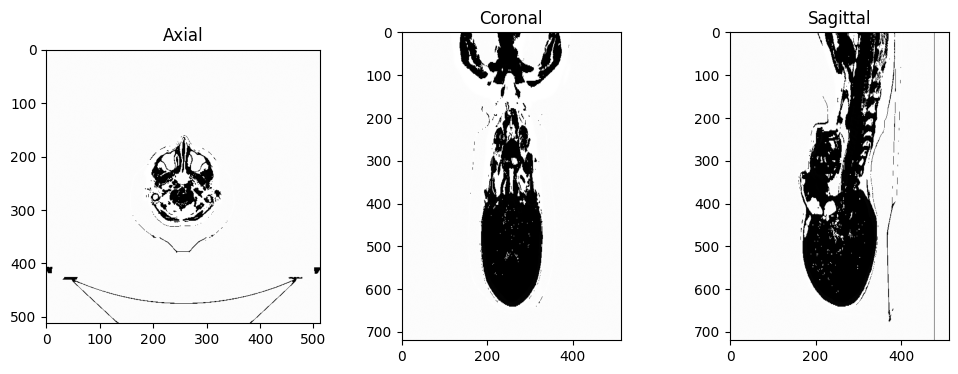

In [6]:
z, y, x = volume.shape

axial = volume[z//2, :, :]
coronal = volume[:, y//2, :]
sagittal = volume[:, :, x//2]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(axial, cmap="gray")
axes[0].set_title("Axial")

axes[1].imshow(coronal, cmap="gray")
axes[1].set_title("Coronal")

axes[2].imshow(sagittal, cmap="gray")
axes[2].set_title("Sagittal")

plt.show()

## RTSTRUCT FILE

---

In [7]:
rtstruct_files = []

for root, dirs, files in os.walk(folder_path):
    for file in files:
        path = os.path.join(root, file)
        try:
            ds = pydicom.dcmread(path, stop_before_pixels=True)
            if hasattr(ds, "Modality") and ds.Modality == "RTSTRUCT":
                rtstruct_files.append(path)
        except:
            pass

print("RTSTRUCT files found:", len(rtstruct_files))
print("RTSTRUCT path:", rtstruct_files[0] if rtstruct_files else "None")

RTSTRUCT files found: 2
RTSTRUCT path: C:\Users\moham\Downloads\Projects\Digital_Twins\a00286cf\20220601_a00286cf_dicom_rtstruct_dosi_3cd5229d1b2daf7c6c9efc2a84414860.dcm


In [8]:
rtstruct = pydicom.dcmread(rtstruct_files[0])

In [9]:
for roi in rtstruct.StructureSetROISequence:
  print(roi.ROINumber, roi.ROIName)

1 OeilG
2 OeilD
3 patient
4 Encephale
5 Tronc
6 CristalD
7 CristalG
8 NOD
9 NOG
10 Chiasma
11 BandeletteOptD
12 BandeletteOptG
13 CochleeD
14 CochleeG
15 ConduitIntD
16 ConduitIntG
17 HippocampeD
18 HippocampeG
19 Hypothalamus
20 LacrymalD
21 LacrymalG
22 ATMD
23 ATMG
24 CorneeD
25 CorneeG
26 RetineD
27 RetineG
28 ParotideD
29 ParotideG
30 Moelle
31 EXTERNAL
32 PTV
34 GTV
35 CTV
36 TroncExt
37 Peau 3mm
38 Hypophyse
39 TroncInt
40 PICOTsup
41 PICOTsupD
42 PICOTsupG
43 PICOTD
44 PICOTG
45 Voies Optiques
48 Patient-PTV
49 Aud_G


In [10]:
ptv_name = "PTV"

oar_list = ["Tronc", "ParotideD", "ParotideG", "Voies Optiques", "Chiasma", "Encephale", "HippocampeD", "HippocampeG", "RetineD", "RetineG"]

In [11]:
if 'build_mask' not in globals():

    def build_mask(rtstruct, roi_name, slices, volume_shape):
        name_to_num = {roi.ROIName: roi.ROINumber for roi in rtstruct.StructureSetROISequence}
        mask = np.zeros(volume_shape, dtype=np.uint8)
        if roi_name not in name_to_num:
            print(f"WARNING: ROI '{roi_name}' not found"); return mask
        roi_num = name_to_num[roi_name]
        contour_seq = None
        for rc in rtstruct.ROIContourSequence:
            if int(rc.ReferencedROINumber) == int(roi_num):
                contour_seq = rc; break
        if contour_seq is None or not hasattr(contour_seq, 'ContourSequence'):
            return mask
        z_positions = [float(s.ImagePositionPatient[2]) for s in slices]
        nrows, ncols = volume_shape[1], volume_shape[2]
        rr, cc = np.meshgrid(np.arange(nrows), np.arange(ncols), indexing='ij')
        grid_pts = np.column_stack([cc.ravel(), rr.ravel()])
        for contour in contour_seq.ContourSequence:
            pts = np.array(contour.ContourData, dtype=float).reshape(-1, 3)
            k = int(np.argmin([abs(zz - pts[0,2]) for zz in z_positions]))
            s = slices[k]; origin = np.array(s.ImagePositionPatient, dtype=float)
            rs, csp = float(s.PixelSpacing[0]), float(s.PixelSpacing[1])
            cols = (pts[:,0] - origin[0]) / csp
            rows = (pts[:,1] - origin[1]) / rs
            poly = np.column_stack([cols, rows])
            inside = Path(poly).contains_points(grid_pts).reshape(nrows, ncols)
            mask[k][inside] = 1
        return mask


In [12]:
def extract_structure_masks(rtstruct, slices, volume_shape, ptv_name, oar_list):

    structures = {}

   
    ptv_mask = build_mask(rtstruct, ptv_name, slices, volume_shape)
    structures["PTV"] = ptv_mask
    print(f"PTV voxels: {np.sum(ptv_mask)}")

    for oar in oar_list:
        oar_mask = build_mask(rtstruct, oar, slices, volume_shape)
        structures[oar] = oar_mask
        print(f"{oar} voxels: {np.sum(oar_mask)}")

    return structures


In [13]:
structures = extract_structure_masks(rtstruct, slices, volume.shape, ptv_name, oar_list)

PTV voxels: 35884
Tronc voxels: 23483
ParotideD voxels: 16445
ParotideG voxels: 15972
Voies Optiques voxels: 2736
Chiasma voxels: 96
Encephale voxels: 1314883
HippocampeD voxels: 1789
HippocampeG voxels: 1571
RetineD voxels: 2829
RetineG voxels: 2888


In [14]:
def compute_ptv_distance_map(ptv_mask, voxel_spacing):

    ptv_inverse = 1 - ptv_mask

    distance_map = distance_transform_edt(ptv_inverse, sampling=voxel_spacing)

    return distance_map

In [15]:
pixel_spacing = slices[0].PixelSpacing
slice_thickness = abs(slices[1].ImagePositionPatient[2] - slices[0].ImagePositionPatient[2])

voxel_spacing = (
    slice_thickness,
    pixel_spacing[0],
    pixel_spacing[1]
)

In [16]:
ptv_mask = structures["PTV"]

distance_map = compute_ptv_distance_map(ptv_mask, voxel_spacing)

In [17]:
def compute_oar_distances(distance_map, structures, oar_list):

    oar_distances = {}

    for oar in oar_list:

        oar_mask = structures[oar]

        distances = distance_map[oar_mask == 1]

        oar_distances[oar] = distances

        print(f"{oar}: {len(distances)} voxels")
        print("Sample distances:", distances[:10], "\n")

    return oar_distances

In [18]:
oar_distances = compute_oar_distances(
    distance_map,
    structures,
    oar_list
)

Tronc: 23483 voxels
Sample distances: [14.76482306 13.89244399 13.         12.08304597 16.1245155  15.23154621
 14.31782106 13.41640786 12.52996409 11.66190379] 

ParotideD: 16445 voxels
Sample distances: [45.607017   44.64302857 47.07440918 46.32493929 45.35416188 44.38468204
 43.41658669 47.5394573  46.57252409 45.607017  ] 

ParotideG: 15972 voxels
Sample distances: [15.        16.        17.        15.        16.        17.
 18.        16.        17.        16.1245155] 

Voies Optiques: 2736 voxels
Sample distances: [10.         10.04987562 10.19803903 10.44030651  9.          9.05538514
  9.21954446  9.48683298  8.          8.        ] 

Chiasma: 96 voxels
Sample distances: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.] 

Encephale: 1314883 voxels
Sample distances: [12.04159458 11.3137085  14.14213562 13.45362405 12.72792206 12.04159458
 11.40175425 10.81665383 10.29563014  9.8488578 ] 

HippocampeD: 1789 voxels
Sample distances: [23.08679276 22.09072203 21.09502311 20.09975124 19.10497317 23.02

In [19]:
import matplotlib.pyplot as plt
import numpy as np

PTV_DOSE   = 70.0          # clinical prescription (Gy)
G_NORM_P95 = 0.081          # 95th-pct |grad D| measured on the NORMALIZED dose cube (per mm)
GRADIENT   = G_NORM_P95 * PTV_DOSE  

# Total-dose OAR tolerances (Gy)
clinical_constraints = {
    "Tronc":54,
    "ParotideD":26,
    "ParotideG":26,
    "Voies Optiques":54,
    "Chiasma":54,
    "Encephale":60,
    "HippocampeD":16,
    "HippocampeG":16,
    "RetineD":45,
    "RetineG":45
}

dc_values = {k: max(0.0, (PTV_DOSE - v) / GRADIENT) for k, v in clinical_constraints.items()}

print(f"Prescription = {PTV_DOSE:.0f} Gy | Gradient G = {GRADIENT:.2f} Gy/mm")
print("Near-compression thresholds d_c (mm):")
for k, v in dc_values.items():
    print(f"   {k:16s} tol={clinical_constraints[k]:>3} Gy  ->  d_c = {v:5.2f} mm")

print("\nVoxel counts:")
for o in oar_list:
    print(f"{o}: {np.sum(structures[o]):,} voxels")

def plot_ddth_per_structure(oar_distances, bins=100):
    for oar, distances in oar_distances.items():
        dc = dc_values[oar]
        w = np.ones_like(distances)/len(distances)
        plt.figure(figsize=(7,4))
        plt.hist(distances, bins=bins, weights=w, color="steelblue", alpha=0.7)
        plt.axvspan(0, 0.001, color="red", alpha=.25, label="Overlap")
        plt.axvspan(0, dc, color="orange", alpha=.20, label="Near compression")
        plt.axvspan(dc, max(distances), color="green", alpha=.12, label="Free zone")
        plt.axvline(dc, color="k", ls="--", label=f"Dc={dc:.2f} mm")
        plt.title(f"dDTH - {oar}")
        plt.xlabel("Distance from PTV (mm)")
        plt.ylabel("Normalized volume fraction")
        plt.legend(); plt.grid(True); plt.show()


Prescription = 70 Gy | Gradient G = 5.67 Gy/mm
Near-compression thresholds d_c (mm):
   Tronc            tol= 54 Gy  ->  d_c =  2.82 mm
   ParotideD        tol= 26 Gy  ->  d_c =  7.76 mm
   ParotideG        tol= 26 Gy  ->  d_c =  7.76 mm
   Voies Optiques   tol= 54 Gy  ->  d_c =  2.82 mm
   Chiasma          tol= 54 Gy  ->  d_c =  2.82 mm
   Encephale        tol= 60 Gy  ->  d_c =  1.76 mm
   HippocampeD      tol= 16 Gy  ->  d_c =  9.52 mm
   HippocampeG      tol= 16 Gy  ->  d_c =  9.52 mm
   RetineD          tol= 45 Gy  ->  d_c =  4.41 mm
   RetineG          tol= 45 Gy  ->  d_c =  4.41 mm

Voxel counts:
Tronc: 23,483 voxels
ParotideD: 16,445 voxels
ParotideG: 15,972 voxels
Voies Optiques: 2,736 voxels
Chiasma: 96 voxels
Encephale: 1,314,883 voxels
HippocampeD: 1,789 voxels
HippocampeG: 1,571 voxels
RetineD: 2,829 voxels
RetineG: 2,888 voxels


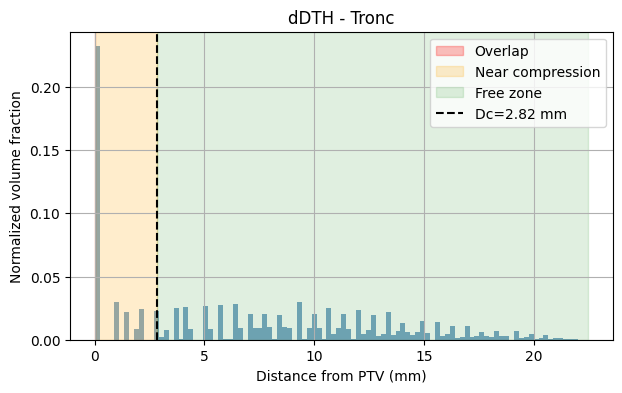

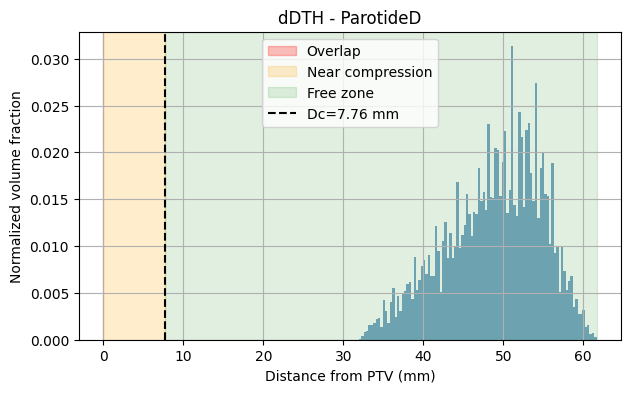

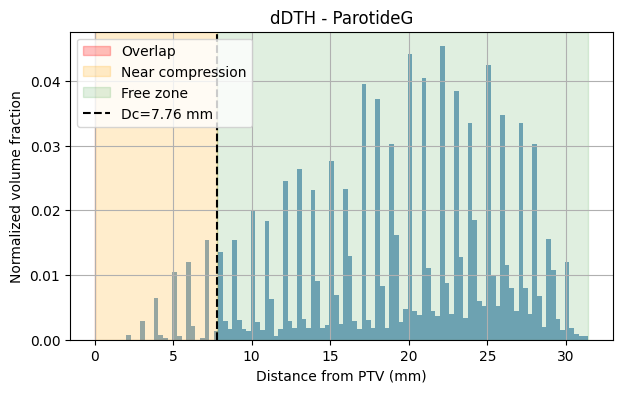

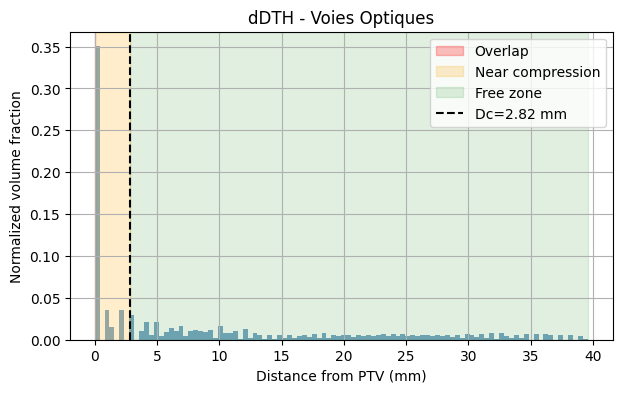

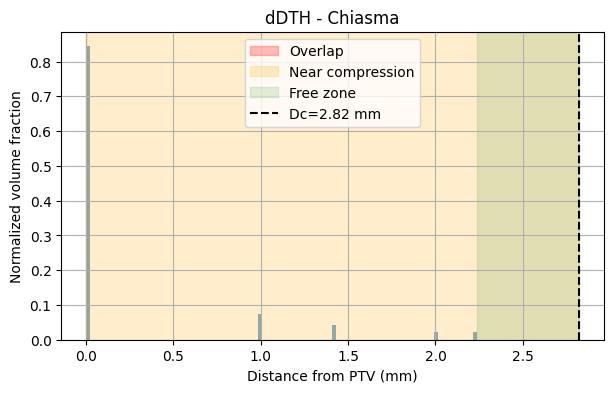

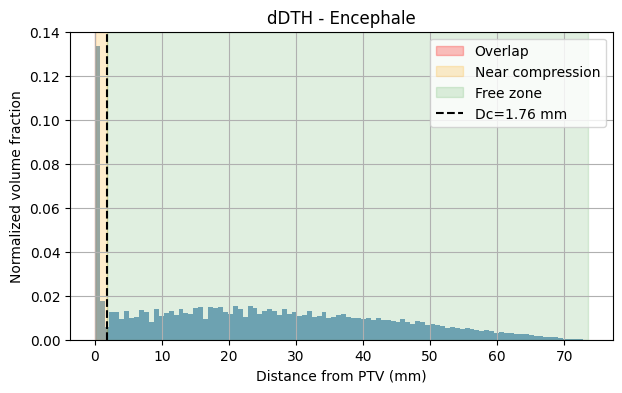

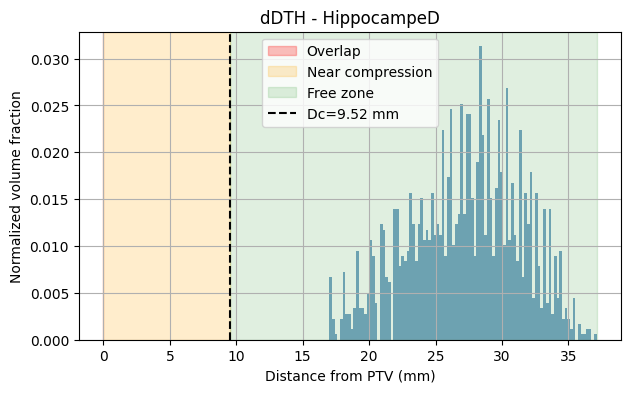

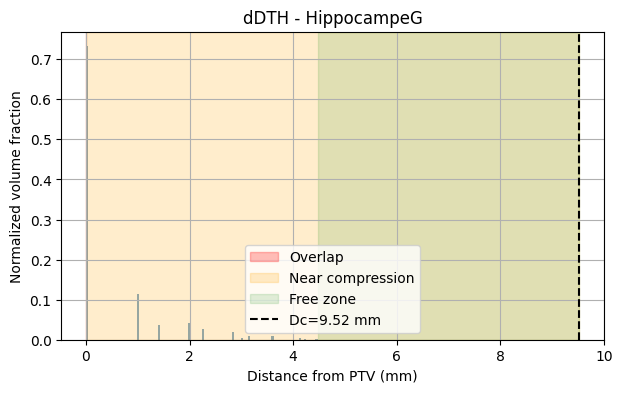

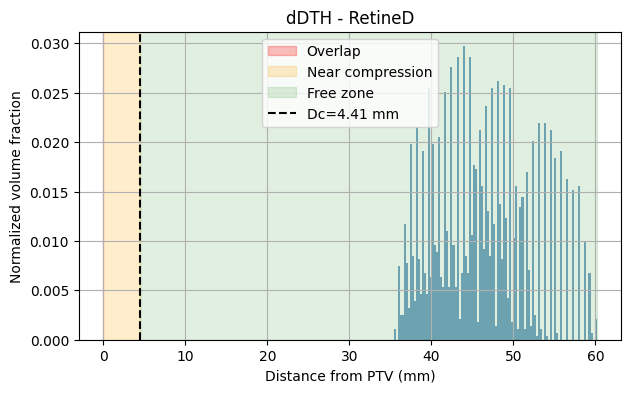

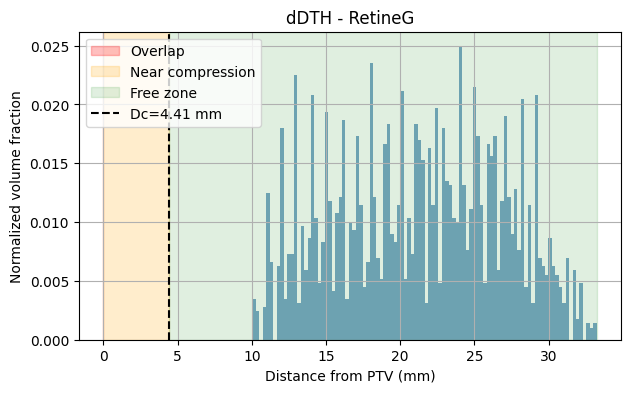

In [20]:
plot_ddth_per_structure(oar_distances)

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def plot_ddth_per_structure(oar_distances, bins=100):

    for oar, distances in oar_distances.items():

        plt.figure(figsize=(6,4))

        weights = np.ones_like(distances) / len(distances)

        plt.hist(distances,
                 bins=bins,
                 weights=weights,
                 histtype='stepfilled',
                 alpha=0.6)

        plt.xlabel("Distance from PTV (mm)")
        plt.ylabel("Normalized Volume Fraction")
        plt.title(f"dDTH - {oar}")

        plt.grid(True)

        plt.show()

In [22]:
def compute_normalized_zones(oar_distances,dc_values):
    normalized={}
    for oar,distances in oar_distances.items():
        dc=dc_values[oar]
        OV=np.sum(distances==0)
        NCV=np.sum((distances>0)&(distances<=dc))
        FSV=np.sum(distances>dc)
        total=len(distances)
        normalized[oar]={
            "OV":OV,"NCV":NCV,"FSV":FSV,
            "NOV":OV/total,"NCV":NCV/total,"NSV":FSV/total}
    return normalized

In [23]:
normalized_zones=compute_normalized_zones(oar_distances,dc_values)
display(pd.DataFrame(normalized_zones).T)

,OV,NCV,FSV,NOV,NSV
Tronc,5450.0,0.084018,16060.0,0.232083,0.683899
ParotideD,0.0,0.000000,16445.0,0.000000,1.000000
ParotideG,0.0,0.053469,15118.0,0.000000,0.946531
Voies Optiques,958.0,0.085526,1544.0,0.350146,0.564327
Chiasma,81.0,0.156250,0.0,0.843750,0.000000
Encephale,175562.0,0.017781,1115941.0,0.133519,0.848700
HippocampeD,0.0,0.000000,1789.0,0.000000,1.000000
HippocampeG,1150.0,0.267982,0.0,0.732018,0.000000
RetineD,0.0,0.000000,2829.0,0.000000,1.000000
RetineG,0.0,0.000000,2888.0,0.000000,1.000000


In [24]:
def compute_gvc(normalized_zones,alpha=1.0,beta=0.5,gamma=0.0):
    rows=[]
    for oar,v in normalized_zones.items():
        gvc=alpha*v["NOV"]+beta*v["NNC"]+gamma*v["NSV"]
        rows.append([oar,v["NOV"],v["NNC"],v["NSV"],gvc])
    import pandas as pd
    df=pd.DataFrame(rows,columns=["Structure","NOV","NNC","NSV","GVC"])
    return df

In [25]:
gvc_results=compute_gvc(normalized_zones)
display(gvc_results)

KeyError: 'NNC'

In [ ]:
# ---- Patient-level GVC = sum_i  w_priority_i * GVC_i^2  (quadratic aggregation) ----
import pandas as pd

# Clinical-priority weights (illustrative - refine with your clinical protocol)
w_priority = {
    "Chiasma":0.90, "Voies Optiques":0.90, "Tronc":0.95, "Encephale":0.75,
    "HippocampeD":0.65, "HippocampeG":0.65,
    "ParotideD":0.50, "ParotideG":0.50, "RetineD":0.70, "RetineG":0.70,
}

g = gvc_results.set_index("Structure")["GVC"]
rows = []
for s, gvc in g.items():
    w = w_priority.get(s, 0.0)
    rows.append([s, gvc, w, gvc**2, w * gvc**2])
agg = pd.DataFrame(rows, columns=["Structure", "GVC", "w_priority", "GVC^2", "w*GVC^2"])
patient_gvc = agg["w*GVC^2"].sum()

display(agg)
print(f"Patient-level GVC = {patient_gvc:.4f}")


,Structure,GVC,w_priority,GVC^2,w*GVC^2
0,Tronc,0.102904,0.95,0.010589,0.010060
1,ParotideD,0.000000,0.50,0.000000,0.000000
2,ParotideG,0.000000,0.50,0.000000,0.000000
3,Voies Optiques,0.281615,0.90,0.079307,0.071377
4,Chiasma,0.619792,0.90,0.384142,0.345728
5,Encephale,0.019121,0.75,0.000366,0.000274
6,HippocampeD,0.000000,0.65,0.000000,0.000000
7,HippocampeG,0.387015,0.65,0.149780,0.097357
8,RetineD,0.000000,0.70,0.000000,0.000000
9,RetineG,0.000000,0.70,0.000000,0.000000


Patient-level GVC = 0.5248
